In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

print("Analytics Engineering environment ready.")

Analytics Engineering environment ready.


In [2]:
predictions_path = "../outputs/ml_predictions.csv"

df = pd.read_csv(predictions_path)

print("Prediction file loaded successfully.")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Prediction file loaded successfully.
Shape: (5, 3)

Columns:
['message', 'prediction', 'spam_probability']


In [3]:
df

,message,prediction,spam_probability
0,Free entry in a weekly competition! Text WIN t...,Spam,0.993298
1,Can you send me the assignment notes?,Ham,0.152444
2,"Congratulations, you have won a cash prize!",Spam,0.997507
3,I'll call you when I reach home.,Ham,0.003694
4,URGENT! Claim your free reward now!,Spam,0.998199


In [4]:
import os

processed_path = "../data/processed"

print("Files in processed data folder:")
print(os.listdir(processed_path))

Files in processed data folder:
['data_quality_report.csv', 'test_clean.csv', 'tfidf_vectorizer.joblib', 'train_clean.csv', 'X_test_tfidf.npz', 'X_train_tfidf.npz', 'y_test.csv', 'y_train.csv']


In [5]:
test_df = pd.read_csv("../data/processed/test_clean.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

print("test_clean shape:", test_df.shape)
print("y_test shape:", y_test.shape)

print("\ntest_clean columns:")
print(test_df.columns.tolist())

print("\ny_test columns:")
print(y_test.columns.tolist())

test_clean shape: (1034, 2)
y_test shape: (1034, 1)

test_clean columns:
['message', 'label']

y_test columns:
['label']


In [6]:
import os

models_path = "../models"

print("Files in models folder:")
print(os.listdir(models_path))

Files in models folder:
['.gitkeep', 'spam_classifier.pkl']


In [7]:
with open("../src/inference.py", "r", encoding="utf-8") as f:
    inference_code = f.read()

print(inference_code)

import os
import joblib

BASE_DIR = os.path.abspath(
    os.path.join(os.path.dirname(__file__), "..")
)

MODEL_PATH = os.path.join(
    BASE_DIR, "models", "spam_classifier.pkl"
)

VECTORIZER_PATH = os.path.join(
    BASE_DIR, "data", "processed", "tfidf_vectorizer.joblib"
)

model = joblib.load(MODEL_PATH)
vectorizer = joblib.load(VECTORIZER_PATH)


def predict_message(message: str):
    """
    Predict whether an SMS message is Ham or Spam.

    Returns:
        label: "Ham" or "Spam"
        spam_probability: probability that the message is Spam
    """
    message_tfidf = vectorizer.transform([message])
    prediction = model.predict(message_tfidf)[0]
    probabilities = model.predict_proba(message_tfidf)[0]

    if prediction == 1:
        label = "Spam"
    else:
        label = "Ham"

    spam_probability = probabilities[1]

    return label, spam_probability


In [8]:
import sys

sys.path.append("../src")

from inference import model, vectorizer

print("Model type:", type(model).__name__)
print("Vectorizer type:", type(vectorizer).__name__)
print("Number of TF-IDF features:", len(vectorizer.vocabulary_))

C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator MultinomialNB from version 1.6.1 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Model type: MultinomialNB
Vectorizer type: TfidfVectorizer
Number of TF-IDF features: 3000


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.2 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.2 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [9]:
# Generate predictions using the existing MLE model and vectorizer

X_test_messages = test_df["message"]

X_test_tfidf = vectorizer.transform(X_test_messages)

predicted_labels = model.predict(X_test_tfidf)
spam_probabilities = model.predict_proba(X_test_tfidf)[:, 1]

ae_df = pd.DataFrame({
    "message": X_test_messages,
    "actual_label": y_test["label"].values,
    "predicted_label": predicted_labels,
    "spam_probability": spam_probabilities
})

print("AE evaluation dataset created.")
print("Shape:", ae_df.shape)

ae_df.head()

AE evaluation dataset created.
Shape: (1034, 4)


,message,actual_label,predicted_label,spam_probability
0,"good morning, my love ... i go to sleep now an...",0,0,0.000102
1,"and how you will do that, princess? :)",0,0,0.004095
2,"cool, i'll text you when i'm on the way",0,0,0.003924
3,your right! i'll make the appointment right now.,0,0,0.008138
4,aiya we discuss later lar... pick ü up at 4 is...,0,0,0.000866


In [10]:
# Verify that test messages and test labels are correctly aligned

labels_match = (
    ae_df["actual_label"].values
    == test_df["label"].values
).all()

print("Message/label alignment:", labels_match)

print("\nActual label distribution:")
print(ae_df["actual_label"].value_counts().sort_index())

print("\nPredicted label distribution:")
print(ae_df["predicted_label"].value_counts().sort_index())

Message/label alignment: True

Actual label distribution:
actual_label
0    903
1    131
Name: count, dtype: int64

Predicted label distribution:
predicted_label
0    912
1    122
Name: count, dtype: int64


In [11]:
# Confusion matrix and classification metrics

cm = confusion_matrix(
    ae_df["actual_label"],
    ae_df["predicted_label"]
)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix")
print(cm)

print("\nBreakdown:")
print("True Negatives  (Ham → Ham):", tn)
print("False Positives (Ham → Spam):", fp)
print("False Negatives (Spam → Ham):", fn)
print("True Positives  (Spam → Spam):", tp)

accuracy = (tp + tn) / (tp + tn + fp + fn)

spam_precision = precision_score(
    ae_df["actual_label"],
    ae_df["predicted_label"],
    zero_division=0
)

spam_recall = recall_score(
    ae_df["actual_label"],
    ae_df["predicted_label"],
    zero_division=0
)

spam_f1 = f1_score(
    ae_df["actual_label"],
    ae_df["predicted_label"],
    zero_division=0
)

print("\nMetrics:")
print(f"Accuracy       : {accuracy:.6f}")
print(f"Spam Precision : {spam_precision:.6f}")
print(f"Spam Recall    : {spam_recall:.6f}")
print(f"Spam F1        : {spam_f1:.6f}")

Confusion Matrix
[[898   5]
 [ 14 117]]

Breakdown:
True Negatives  (Ham → Ham): 898
False Positives (Ham → Spam): 5
False Negatives (Spam → Ham): 14
True Positives  (Spam → Spam): 117

Metrics:
Accuracy       : 0.981625
Spam Precision : 0.959016
Spam Recall    : 0.893130
Spam F1        : 0.924901


In [12]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    ae_df["actual_label"],
    ae_df["spam_probability"]
)

print(f"Spam PR-AUC: {pr_auc:.6f}")
print(f"Spam PR-AUC: {pr_auc * 100:.4f}%")

Spam PR-AUC: 0.970789
Spam PR-AUC: 97.0789%


In [13]:
def classify_error(row):
    actual = row["actual_label"]
    predicted = row["predicted_label"]

    if actual == 1 and predicted == 1:
        return "True Positive"

    elif actual == 0 and predicted == 0:
        return "True Negative"

    elif actual == 0 and predicted == 1:
        return "False Positive"

    elif actual == 1 and predicted == 0:
        return "False Negative"

    return "Unknown"


ae_df["error_type"] = ae_df.apply(classify_error, axis=1)

print(ae_df["error_type"].value_counts())

error_type
True Negative     898
True Positive     117
False Negative     14
False Positive      5
Name: count, dtype: int64


In [14]:
#Inspect the 5 False Positives
false_positives = ae_df[
    ae_df["error_type"] == "False Positive"
].copy()

print("Number of false positives:", len(false_positives))

false_positives[
    ["message", "actual_label", "predicted_label", "spam_probability"]
]

Number of false positives: 5


,message,actual_label,predicted_label,spam_probability
293,are you free now?can i call now?,0,1,0.526718
327,k k:) sms chat with me.,0,1,0.695028
494,"received, understood n acted upon!",0,1,0.853169
689,unlimited texts. limited minutes.,0,1,0.638636
737,have you laid your airtel line to rest?,0,1,0.675561


In [15]:
#Inspect the 14 False Negatives
false_negatives = ae_df[
    ae_df["error_type"] == "False Negative"
].copy()

print("Number of false negatives:", len(false_negatives))

false_negatives[
    ["message", "actual_label", "predicted_label", "spam_probability"]
]

Number of false negatives: 14


,message,actual_label,predicted_label,spam_probability
79,thanks for the vote. now sing along with the s...,1,0,0.486517
168,hi if ur lookin 4 saucy daytime fun wiv busty ...,1,0,0.054666
230,asked 3mobile if 0870 chatlines inclu in free ...,1,0,0.423715
308,hi its lucy hubby at meetins all day fri & i w...,1,0,0.044131
326,missed call alert. these numbers called but le...,1,0,0.129617
329,"sms. ac sun0819 posts hello:""you seem cool, wa...",1,0,0.310370
437,babe: u want me dont u baby! im nasty and have...,1,0,0.013547
456,check out choose your babe videos @ sms.shsex....,1,0,0.233066
468,88066 from 88066 lost 3pound help,1,0,0.098208
486,in the simpsons movie released in july 2007 na...,1,0,0.008097


In [16]:
#quantify the error probabilities
fp_summary = false_positives["spam_probability"].describe()
fn_summary = false_negatives["spam_probability"].describe()

print("False Positive probability summary:")
print(fp_summary)

print("\nFalse Negative probability summary:")
print(fn_summary)

False Positive probability summary:
count    5.000000
mean     0.677822
std      0.117702
min      0.526718
25%      0.638636
50%      0.675561
75%      0.695028
max      0.853169
Name: spam_probability, dtype: float64

False Negative probability summary:
count    14.000000
mean      0.212582
std       0.173703
min       0.008097
25%       0.065551
50%       0.160320
75%       0.365323
max       0.486517
Name: spam_probability, dtype: float64


In [17]:
#treshold analysis
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    threshold_predictions = (
        ae_df["spam_probability"] >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        ae_df["actual_label"],
        threshold_predictions
    ).ravel()

    precision = precision_score(
        ae_df["actual_label"],
        threshold_predictions,
        zero_division=0
    )

    recall = recall_score(
        ae_df["actual_label"],
        threshold_predictions,
        zero_division=0
    )

    f1 = f1_score(
        ae_df["actual_label"],
        threshold_predictions,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.round(4))

    threshold  precision  recall      f1  true_negatives  false_positives  \
0        0.10     0.6774  0.9618  0.7950             843               60   
1        0.15     0.8267  0.9466  0.8826             877               26   
2        0.20     0.8542  0.9389  0.8945             882               21   
3        0.25     0.8714  0.9313  0.9004             885               18   
4        0.30     0.8905  0.9313  0.9104             888               15   
5        0.35     0.9237  0.9237  0.9237             893               10   
6        0.40     0.9524  0.9160  0.9339             897                6   
7        0.45     0.9520  0.9084  0.9297             897                6   
8        0.50     0.9590  0.8931  0.9249             898                5   
9        0.55     0.9661  0.8702  0.9157             899                4   
10       0.60     0.9661  0.8702  0.9157             899                4   
11       0.65     0.9741  0.8626  0.9150             900                3   

In [18]:
#calculate the operational change from the current 0.50 threshold
baseline = threshold_df[threshold_df["threshold"] == 0.50].iloc[0]

comparison_thresholds = threshold_df[
    threshold_df["threshold"].isin([0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.70])
].copy()

comparison_thresholds["fp_change_vs_0.50"] = (
    comparison_thresholds["false_positives"] - baseline["false_positives"]
)

comparison_thresholds["fn_change_vs_0.50"] = (
    comparison_thresholds["false_negatives"] - baseline["false_negatives"]
)

comparison_thresholds["precision_pct"] = (
    comparison_thresholds["precision"] * 100
).round(2)

comparison_thresholds["recall_pct"] = (
    comparison_thresholds["recall"] * 100
).round(2)

print(
    comparison_thresholds[
        [
            "threshold",
            "precision_pct",
            "recall_pct",
            "false_positives",
            "false_negatives",
            "fp_change_vs_0.50",
            "fn_change_vs_0.50"
        ]
    ].to_string(index=False)
)

IndexError: single positional indexer is out-of-bounds

In [19]:
baseline = threshold_df[
    np.isclose(threshold_df["threshold"], 0.50)
].iloc[0]

comparison_thresholds = threshold_df[
    threshold_df["threshold"].apply(
        lambda x: np.any(np.isclose(x, [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.70]))
    )
].copy()

comparison_thresholds["fp_change_vs_0.50"] = (
    comparison_thresholds["false_positives"]
    - baseline["false_positives"]
)

comparison_thresholds["fn_change_vs_0.50"] = (
    comparison_thresholds["false_negatives"]
    - baseline["false_negatives"]
)

comparison_thresholds["precision_pct"] = (
    comparison_thresholds["precision"] * 100
).round(2)

comparison_thresholds["recall_pct"] = (
    comparison_thresholds["recall"] * 100
).round(2)

print(
    comparison_thresholds[
        [
            "threshold",
            "precision_pct",
            "recall_pct",
            "false_positives",
            "false_negatives",
            "fp_change_vs_0.50",
            "fn_change_vs_0.50"
        ]
    ].to_string(index=False)
)

 threshold  precision_pct  recall_pct  false_positives  false_negatives  fp_change_vs_0.50  fn_change_vs_0.50
      0.30          89.05       93.13               15                9               10.0               -5.0
      0.35          92.37       92.37               10               10                5.0               -4.0
      0.40          95.24       91.60                6               11                1.0               -3.0
      0.45          95.20       90.84                6               12                1.0               -2.0
      0.50          95.90       89.31                5               14                0.0                0.0
      0.55          96.61       87.02                4               17               -1.0                3.0
      0.60          96.61       87.02                4               17               -1.0                3.0
      0.70          99.12       85.50                1               19               -4.0                5.0


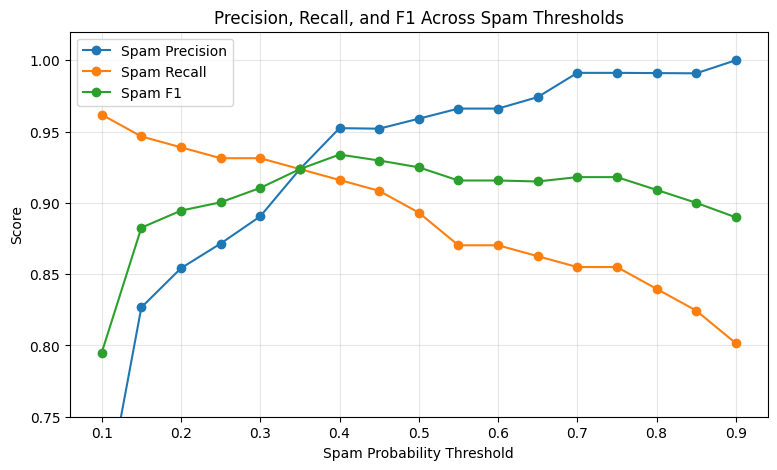

In [20]:
#visualize business trade-off between false alarms and missed spam
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Spam Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Spam Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="Spam F1"
)

plt.xlabel("Spam Probability Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Across Spam Thresholds")
plt.ylim(0.75, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [21]:
# Hypothetical business impact assumptions
# These are scenario values for analysis, NOT measured enterprise costs.

FP_COST = 5    # Cost of incorrectly flagging a legitimate message
FN_COST = 20   # Cost of missing a spam message

cost_df = threshold_df.copy()

cost_df["hypothetical_cost"] = (
    cost_df["false_positives"] * FP_COST
    + cost_df["false_negatives"] * FN_COST
)

cost_df["fp_cost"] = (
    cost_df["false_positives"] * FP_COST
)

cost_df["fn_cost"] = (
    cost_df["false_negatives"] * FN_COST
)

print(
    cost_df[
        [
            "threshold",
            "false_positives",
            "false_negatives",
            "fp_cost",
            "fn_cost",
            "hypothetical_cost"
        ]
    ].round(2).to_string(index=False)
)

 threshold  false_positives  false_negatives  fp_cost  fn_cost  hypothetical_cost
      0.10               60                5      300      100                400
      0.15               26                7      130      140                270
      0.20               21                8      105      160                265
      0.25               18                9       90      180                270
      0.30               15                9       75      180                255
      0.35               10               10       50      200                250
      0.40                6               11       30      220                250
      0.45                6               12       30      240                270
      0.50                5               14       25      280                305
      0.55                4               17       20      340                360
      0.60                4               17       20      340                360
      0.65      

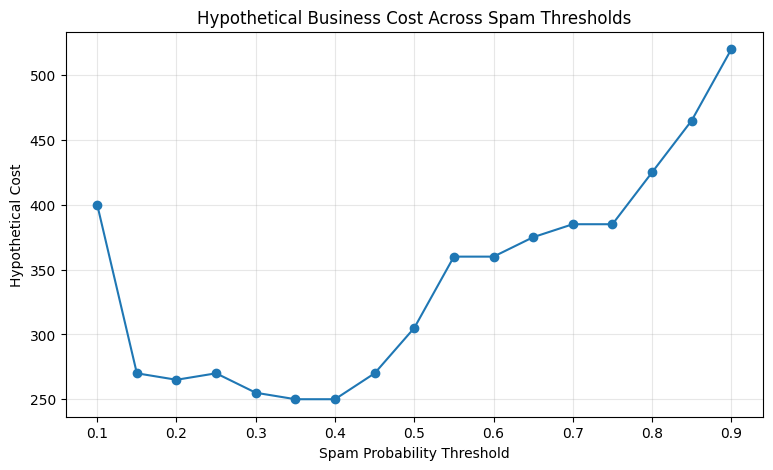

In [22]:
#visualize the hypothetical business cost
plt.figure(figsize=(9, 5))

plt.plot(
    cost_df["threshold"],
    cost_df["hypothetical_cost"],
    marker="o"
)

plt.xlabel("Spam Probability Threshold")
plt.ylabel("Hypothetical Cost")
plt.title("Hypothetical Business Cost Across Spam Thresholds")
plt.grid(True, alpha=0.3)

plt.show()

In [23]:
#create the KPI summary
baseline_row = threshold_df[
    np.isclose(threshold_df["threshold"], 0.50)
].iloc[0]

kpi_summary = pd.DataFrame({
    "KPI": [
        "Test Messages",
        "Actual Spam Messages",
        "Actual Ham Messages",
        "Spam Precision",
        "Spam Recall",
        "Spam F1",
        "False Positives",
        "False Negatives",
        "True Positives",
        "True Negatives",
        "Spam PR-AUC",
        "Baseline Threshold",
        "Hypothetical FP Cost",
        "Hypothetical FN Cost"
    ],
    "Value": [
        len(ae_df),
        int((ae_df["actual_label"] == 1).sum()),
        int((ae_df["actual_label"] == 0).sum()),
        round(baseline_row["precision"] * 100, 2),
        round(baseline_row["recall"] * 100, 2),
        round(baseline_row["f1"] * 100, 2),
        int(baseline_row["false_positives"]),
        int(baseline_row["false_negatives"]),
        int(baseline_row["true_positives"]),
        int(baseline_row["true_negatives"]),
        97.0789,
        0.50,
        FP_COST,
        FN_COST
    ]
})

print(kpi_summary.to_string(index=False))

                 KPI     Value
       Test Messages 1034.0000
Actual Spam Messages  131.0000
 Actual Ham Messages  903.0000
      Spam Precision   95.9000
         Spam Recall   89.3100
             Spam F1   92.4900
     False Positives    5.0000
     False Negatives   14.0000
      True Positives  117.0000
      True Negatives  898.0000
         Spam PR-AUC   97.0789
  Baseline Threshold    0.5000
Hypothetical FP Cost    5.0000
Hypothetical FN Cost   20.0000


In [24]:
#AE prediction dataset
ae_predictions = ae_df.copy()

ae_predictions["risk_level"] = pd.cut(
    ae_predictions["spam_probability"],
    bins=[-0.01, 0.30, 0.70, 1.00],
    labels=["Low", "Medium", "High"]
)

ae_predictions.to_csv(
    "../outputs/ae_predictions.csv",
    index=False
)

print("AE prediction dataset created.")
print("Shape:", ae_predictions.shape)
print("Columns:", list(ae_predictions.columns))
print("\nRisk distribution:")
print(ae_predictions["risk_level"].value_counts().sort_index())

AE prediction dataset created.
Shape: (1034, 6)
Columns: ['message', 'actual_label', 'predicted_label', 'spam_probability', 'error_type', 'risk_level']

Risk distribution:
risk_level
Low       897
Medium     24
High      113
Name: count, dtype: int64


In [25]:
#saving the threshold analysis
threshold_df.to_csv(
    "../outputs/threshold_analysis.csv",
    index=False
)

print("Threshold analysis dataset created.")
print("Shape:", threshold_df.shape)
print("Saved columns:")
print(list(threshold_df.columns))

Threshold analysis dataset created.
Shape: (17, 8)
Saved columns:
['threshold', 'precision', 'recall', 'f1', 'true_negatives', 'false_positives', 'false_negatives', 'true_positives']


In [26]:
#saving the KPI summary
kpi_summary.to_csv(
    "../outputs/business_kpis.csv",
    index=False
)

print("Business KPI dataset created.")
print("Shape:", kpi_summary.shape)
print("Saved to: ../outputs/business_kpis.csv")

Business KPI dataset created.
Shape: (14, 2)
Saved to: ../outputs/business_kpis.csv


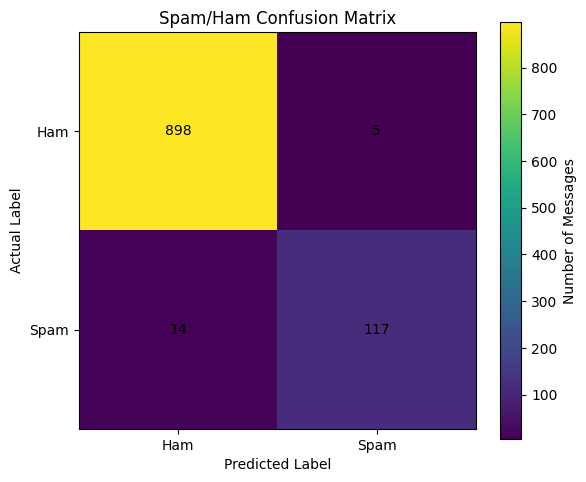

In [27]:
cm = confusion_matrix(
    ae_df["actual_label"],
    ae_df["predicted_label"]
)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Spam/Ham Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Ham", "Spam"])
plt.yticks([0, 1], ["Ham", "Spam"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(label="Number of Messages")
plt.tight_layout()
plt.show()

In [28]:
#verify AE output files
import os

ae_outputs = [
    "../outputs/ae_predictions.csv",
    "../outputs/threshold_analysis.csv",
    "../outputs/business_kpis.csv"
]

for path in ae_outputs:
    print(
        os.path.basename(path),
        "→",
        "EXISTS" if os.path.exists(path) else "MISSING"
    )

ae_predictions.csv → EXISTS
threshold_analysis.csv → EXISTS
business_kpis.csv → EXISTS
